In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm
import getFamaFrenchFactors as gff

In [34]:
rets = yf.download(['VTI','AVUV','^SPX'], interval = '1mo', auto_adjust = True, start = '2000-01-01')['Close']
rets = rets.to_period('M').pct_change().dropna()

[*********************100%***********************]  3 of 3 completed


In [35]:
rets.tail()

Ticker,AVUV,VTI,^SPX
Date,,,
2026-03,-0.019698,-0.050048,-0.050933
2026-04,0.087535,0.104018,0.104233
2026-05,-0.000749,0.051838,0.051470
2026-06,0.043055,-0.003853,-0.010646
2026-07,0.004208,-0.010404,-0.007859


In [36]:
ff_5f = gff.famaFrench5Factor().set_index('date_ff_factors').to_period('M')
ff_momentum = gff.momentumFactor().set_index('date_ff_factors').to_period('M')

<Axes: xlabel='date_ff_factors'>

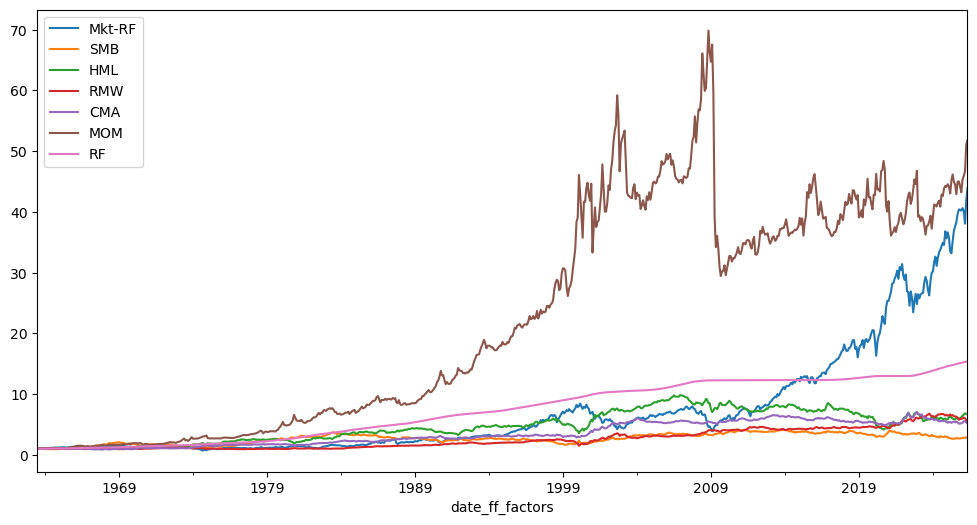

In [37]:
ff_6f = ff_5f.join(ff_momentum)
ff_6f = ff_6f[[*ff_6f.columns.drop('RF'),'RF']]
(1+ff_6f).cumprod().plot(figsize=(12,6))

In [38]:
def factor_regression(rets, factor_model):
    # common index
    common_idx = rets.index.intersection(factor_model.index)
    rets = rets.loc[common_idx]
    factor_model = factor_model.loc[common_idx]

    # prep data for regression
    rets_excess = rets - factor_model[['RF']].values
    factor_model_minus_RFR = factor_model[[*ff_6f.columns.drop('RF')]]
    factor_model_minus_RFR['Alpha'] = 1

    # run regression
    lm = sm.OLS(rets_excess, factor_model_minus_RFR).fit()
    factor_loadings = lm.params
    factor_loadings.columns = rets.columns

    # calculate annualized alpha
    alpha_per_period = factor_loadings.loc[['Alpha']]
    annualized_alpha = ((1+alpha_per_period)**12)-1
    annualized_alpha.index = ['Annualized Alpha']
    factor_loadings = pd.concat([factor_loadings, annualized_alpha])

    # alpha & annualized alpha in %
    factor_loadings = factor_loadings.round(2)
    factor_loadings = factor_loadings.astype(object)
    factor_loadings.loc[['Alpha']] = (alpha_per_period * 100).round(2).astype(str) + '%'
    factor_loadings.loc[['Annualized Alpha']] = (annualized_alpha * 100).round(2).astype(str) + '%'

    return factor_loadings

In [39]:
factor_regression(rets, ff_6f)

Ticker,AVUV,VTI,^SPX
Mkt-RF,1.06,0.99,0.99
SMB,0.9,-0.01,-0.12
HML,0.53,0.03,0.03
RMW,0.27,0.02,0.05
CMA,-0.05,-0.01,0.01
MOM,-0.02,0.0,-0.0
Alpha,0.07%,-0.03%,-0.14%
Annualized Alpha,0.84%,-0.39%,-1.62%


In [40]:
def rolling_factor_regression(rets, factor_model, roll_window=36):
    # common index
    common_idx = rets.index.intersection(factor_model.index)
    rets = rets.loc[common_idx]
    factor_model = factor_model.loc[common_idx]

    # prep data for regression
    rets_excess = rets - factor_model[['RF']].values
    factor_model_minus_RF = factor_model[[*ff_6f.columns.drop('RF')]]

    # rolling
    n_periods = rets.shape[0]
    windows = [(start, start + roll_window) for start in range(n_periods - roll_window + 1)]

    if n_periods <= roll_window:
        print('Sample smaller than roll window.')
        return
    
    # rolling regression
    results = {}
    for ret_excess in rets_excess:
        factor_loadings_per_window = []
        for win in windows:
            lm = sm.OLS(rets_excess[ret_excess].iloc[win[0]:win[1]], factor_model_minus_RF.iloc[win[0]:win[1]]).fit()
            factor_loadings = lm.params
            factor_loadings['date'] = rets_excess.index[win[1] - 1]
            factor_loadings_per_window.append(factor_loadings)
        results[ret_excess] = pd.DataFrame(factor_loadings_per_window).set_index('date')

    return results

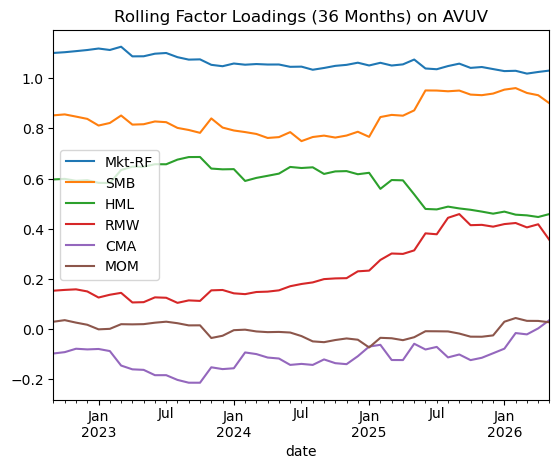

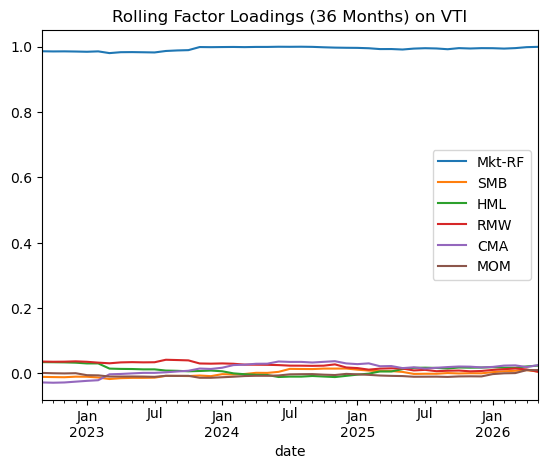

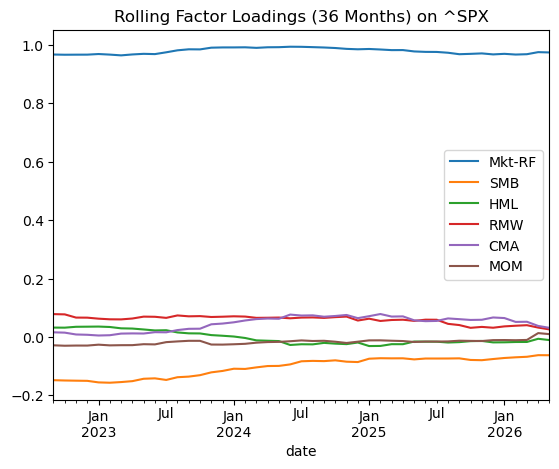

In [41]:
roll_window = 36

results = rolling_factor_regression(rets, ff_6f, roll_window)

for ticker in results:
    results[ticker].plot(title=f'Rolling Factor Loadings ({roll_window} Months) on {ticker}')